# Phishing Website Detection using Machine Learning (UCI - 10 URL-Based Features)

This notebook implements Experiment 2 of the dissertation. It uses a reduced subset of 10 URL-based features from the UCI Phishing Websites Dataset to enable fair cross-dataset comparison with the PhishTank dataset (Experiment 3). Three machine learning models are trained and compared: Logistic Regression, Decision Tree, and Random Forest. The best-performing model is then explained using SHAP and LIME.

The 10 selected features are: having_IP_Address, URL_Length, Shortining_Service, having_At_Symbol, double_slash_redirecting, Prefix_Suffix, having_Sub_Domain, HTTPS_token, port, and Abnormal_URL.


In [2]:
# Importing Libraries:
# In this section, the necessary Python libraries for data analysis, visualization and machine learning are imported.
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')

In [3]:
import os, shutil
# Creating data folder next to your notebook
os.makedirs("data", exist_ok=True)
# Copying the file in
shutil.copy(
    "/Users/monika/Downloads/phishing+websites/Training Dataset.arff","data/Training Dataset.arff")
print("Done")

Done


In [4]:
# we are using scipy.io.arff to read ARFF datasets 
from scipy.io import arff 
# Loading the phishing dataset from ARFF file
data, meta = arff.loadarff("data/Training Dataset.arff")  # relative path - place the .arff file in a 'data' folder in the repo
phishing_df_10 = pd.DataFrame(data)

In [5]:
phishing_df_10.head()
#Preview the dataset by displaying the first five default rows

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,b'-1',b'1',b'1',b'1',b'-1',b'-1',b'-1',b'-1',b'-1',b'1',...,b'1',b'1',b'-1',b'-1',b'-1',b'-1',b'1',b'1',b'-1',b'-1'
1,b'1',b'1',b'1',b'1',b'1',b'-1',b'0',b'1',b'-1',b'1',...,b'1',b'1',b'-1',b'-1',b'0',b'-1',b'1',b'1',b'1',b'-1'
2,b'1',b'0',b'1',b'1',b'1',b'-1',b'-1',b'-1',b'-1',b'1',...,b'1',b'1',b'1',b'-1',b'1',b'-1',b'1',b'0',b'-1',b'-1'
3,b'1',b'0',b'1',b'1',b'1',b'-1',b'-1',b'-1',b'1',b'1',...,b'1',b'1',b'-1',b'-1',b'1',b'-1',b'1',b'-1',b'1',b'-1'
4,b'1',b'0',b'-1',b'1',b'1',b'-1',b'1',b'1',b'-1',b'1',...,b'-1',b'1',b'-1',b'-1',b'0',b'-1',b'1',b'1',b'1',b'1'


In [6]:
# When reading ARFF files, all values are loaded as byte strings (for example b'-1' instead of -1).I converted all columns to integers so the data can be used properly in machine learning models.
# Convert byte strings to integers for proper numerical processing
for col in phishing_df_10.columns:
    if phishing_df_10[col].dtype == object:
        phishing_df_10[col] = phishing_df_10[col].str.decode("utf-8").astype(int)

In [7]:
phishing_df_10.head()

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [8]:
phishing_df_10.columns
# Displaying all column names including features and targets

Index(['having_IP_Address', 'URL_Length', 'Shortining_Service',
       'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix',
       'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length',
       'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor',
       'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL',
       'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe',
       'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank',
       'Google_Index', 'Links_pointing_to_page', 'Statistical_report',
       'Result'],
      dtype='object')

In [9]:
# Defining  the 10 stable URL-based features for PhishTank cross-dataset validation
selected_features = [
    'having_IP_Address',
    'URL_Length',
    'Shortining_Service',
    'having_At_Symbol',
    'double_slash_redirecting',
    'Prefix_Suffix',
    'having_Sub_Domain',
    'HTTPS_token',
    'port',
    'Abnormal_URL']

# Selecting features and target
X = phishing_df_10[selected_features]  # X contains the 10 URL-based features
y = phishing_df_10['Result']   # y is the target variable: -1 = phishing, 1 = legitimate

In [10]:
print("Features shape:", X.shape)  # Checking the shape of selected features and target variable
# This helps confirm that the dataset contains 10 input features and the correct number of labels
print("Target shape:", y.shape)
# Displaying the distribution of target classes
# This helps understand whether the dataset is balanced before training the models
print("\nTarget distribution:\n", y.value_counts())

Features shape: (11055, 10)
Target shape: (11055,)

Target distribution:
 Result
 1    6157
-1    4898
Name: count, dtype: int64


In [11]:
# Removing duplicates for consistency with benchmark notebook
phishing_df_10 = phishing_df_10.drop_duplicates()
phishing_df_10 = phishing_df_10.reset_index(drop=True)

# Re-select features after duplicate removal
X = phishing_df_10[selected_features]
y = phishing_df_10['Result']

print("Shape after duplicate removal:", phishing_df_10.shape)
print("\nTarget distribution:\n", y.value_counts())

Shape after duplicate removal: (5849, 31)

Target distribution:
 Result
-1    3019
 1    2830
Name: count, dtype: int64


In [12]:
print(X.shape)
print(y.shape)

(5849, 10)
(5849,)


In [13]:
# Splitting the dataset into training and testing sets
# Stratified split is used to maintain class balance in both sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

In [14]:
# Checking the shape of training and testing sets. This helps confirm that the dataset has been split correctly
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(4679, 10)
(1170, 10)
Result
-1    2415
 1    2264
Name: count, dtype: int64
Result
-1    604
 1    566
Name: count, dtype: int64


# Logistic Regression

In [16]:
from sklearn.preprocessing import StandardScaler
# Create scaler object
scaler = StandardScaler()
# Fit the scaler on the training data and also transform it. This makes sure all features have mean = 0 and std = 1
X_train_scaled = scaler.fit_transform(X_train)
# Using the same scaler to transform test data, # Important: I only transform, not fitting again, to avoid data leakage
X_test_scaled = scaler.transform(X_test)

In [17]:
# Convert scaled arrays back to DataFrames to retain feature names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

In [18]:
# Training Logistic Regression Model
from sklearn.linear_model import LogisticRegression
# Creating the Logistic Regression model
logit_model = LogisticRegression(max_iter=2000, random_state=42)
# Fitting the model on the scaled training data
logit_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [19]:
# Predicting class labels
y_pred = logit_model.predict(X_test_scaled)
# Predicting probabilities for ROC-AUC calculation
y_prob = logit_model.predict_proba(X_test_scaled)[:, 1]

In [20]:
# Evaluating Logistic Regression Model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
# Calculate accuracy
logit_accuracy = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", logit_accuracy)
# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
# Print confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Logistic Regression Accuracy: 0.7324786324786324

Classification Report:
              precision    recall  f1-score   support

          -1       0.71      0.83      0.76       604
           1       0.77      0.63      0.70       566

    accuracy                           0.73      1170
   macro avg       0.74      0.73      0.73      1170
weighted avg       0.74      0.73      0.73      1170


Confusion Matrix:
[[499 105]
 [208 358]]


In [21]:
# ROC-AUC Score
from sklearn.metrics import roc_auc_score
logit_auc = roc_auc_score(y_test, y_prob)
print("Logistic Regression ROC-AUC Score:", logit_auc)


Logistic Regression ROC-AUC Score: 0.7802591088854046


<Figure size 700x700 with 0 Axes>

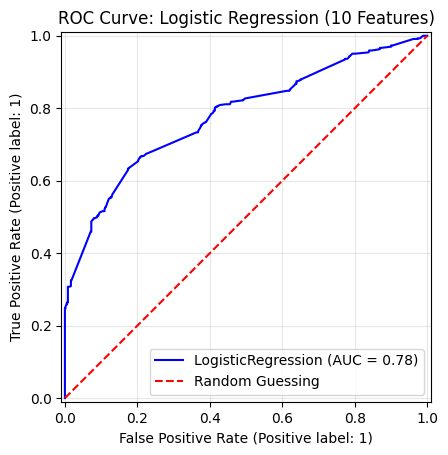

In [22]:
# ROC Curve : plotting the ROC curve to see how well my Logistic Regression model is doing. ROC curve shows the trade-off between True Positive Rate and False Positive Rate
from sklearn.metrics import RocCurveDisplay
plt.figure(figsize=(7, 7))
RocCurveDisplay.from_estimator(logit_model, X_test_scaled, y_test, color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Guessing')
plt.title("ROC Curve: Logistic Regression (10 Features)")  # Adding title, grid, and legend to make it clear
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Decision Tree

In [24]:
from sklearn.tree import DecisionTreeClassifier
# Creating Decision Tree model
dtree = DecisionTreeClassifier(random_state=42)
# Training  the model
dtree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [25]:
# Training the model
dtree.fit(X_train, y_train)
# Predicting class labels
y_pred_dt = dtree.predict(X_test)
# Predict probabilities for ROC-AUC
y_prob_dt = dtree.predict_proba(X_test)[:, 1]
# Note: No scaling needed for Decision Trees as they split based on thresholds not distance

In [26]:
# Evaluating Decision Tree Performance
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7427350427350428

Classification Report:
              precision    recall  f1-score   support

          -1       0.72      0.82      0.77       604
           1       0.77      0.66      0.71       566

    accuracy                           0.74      1170
   macro avg       0.75      0.74      0.74      1170
weighted avg       0.75      0.74      0.74      1170


Confusion Matrix:
[[494 110]
 [191 375]]


In [27]:
# Calculating ROC-AUC score
dt_auc = roc_auc_score(y_test, y_prob_dt)
print("Decision Tree ROC-AUC Score:", dt_auc)

Decision Tree ROC-AUC Score: 0.8118564692392297


<Figure size 700x700 with 0 Axes>

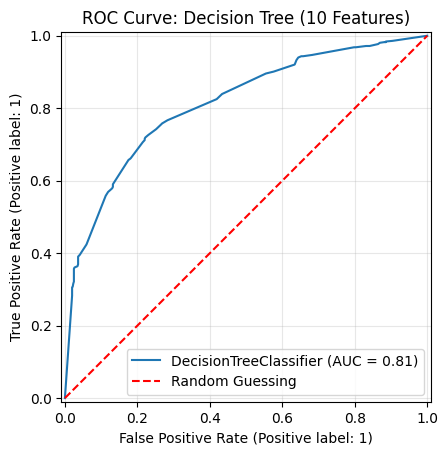

In [28]:
# Plotting ROC curve
plt.figure(figsize=(7, 7))
RocCurveDisplay.from_estimator(dtree, X_test, y_test)
plt.plot([0, 1], [0, 1], 'r--', label="Random Guessing")
plt.title("ROC Curve: Decision Tree (10 Features)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [29]:
# Checking for overfitting by comparing training and testing accuracy
train_accuracy = dtree.score(X_train, y_train)
test_accuracy = dtree.score(X_test, y_test)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.7740970292797607
Testing Accuracy: 0.7427350427350428


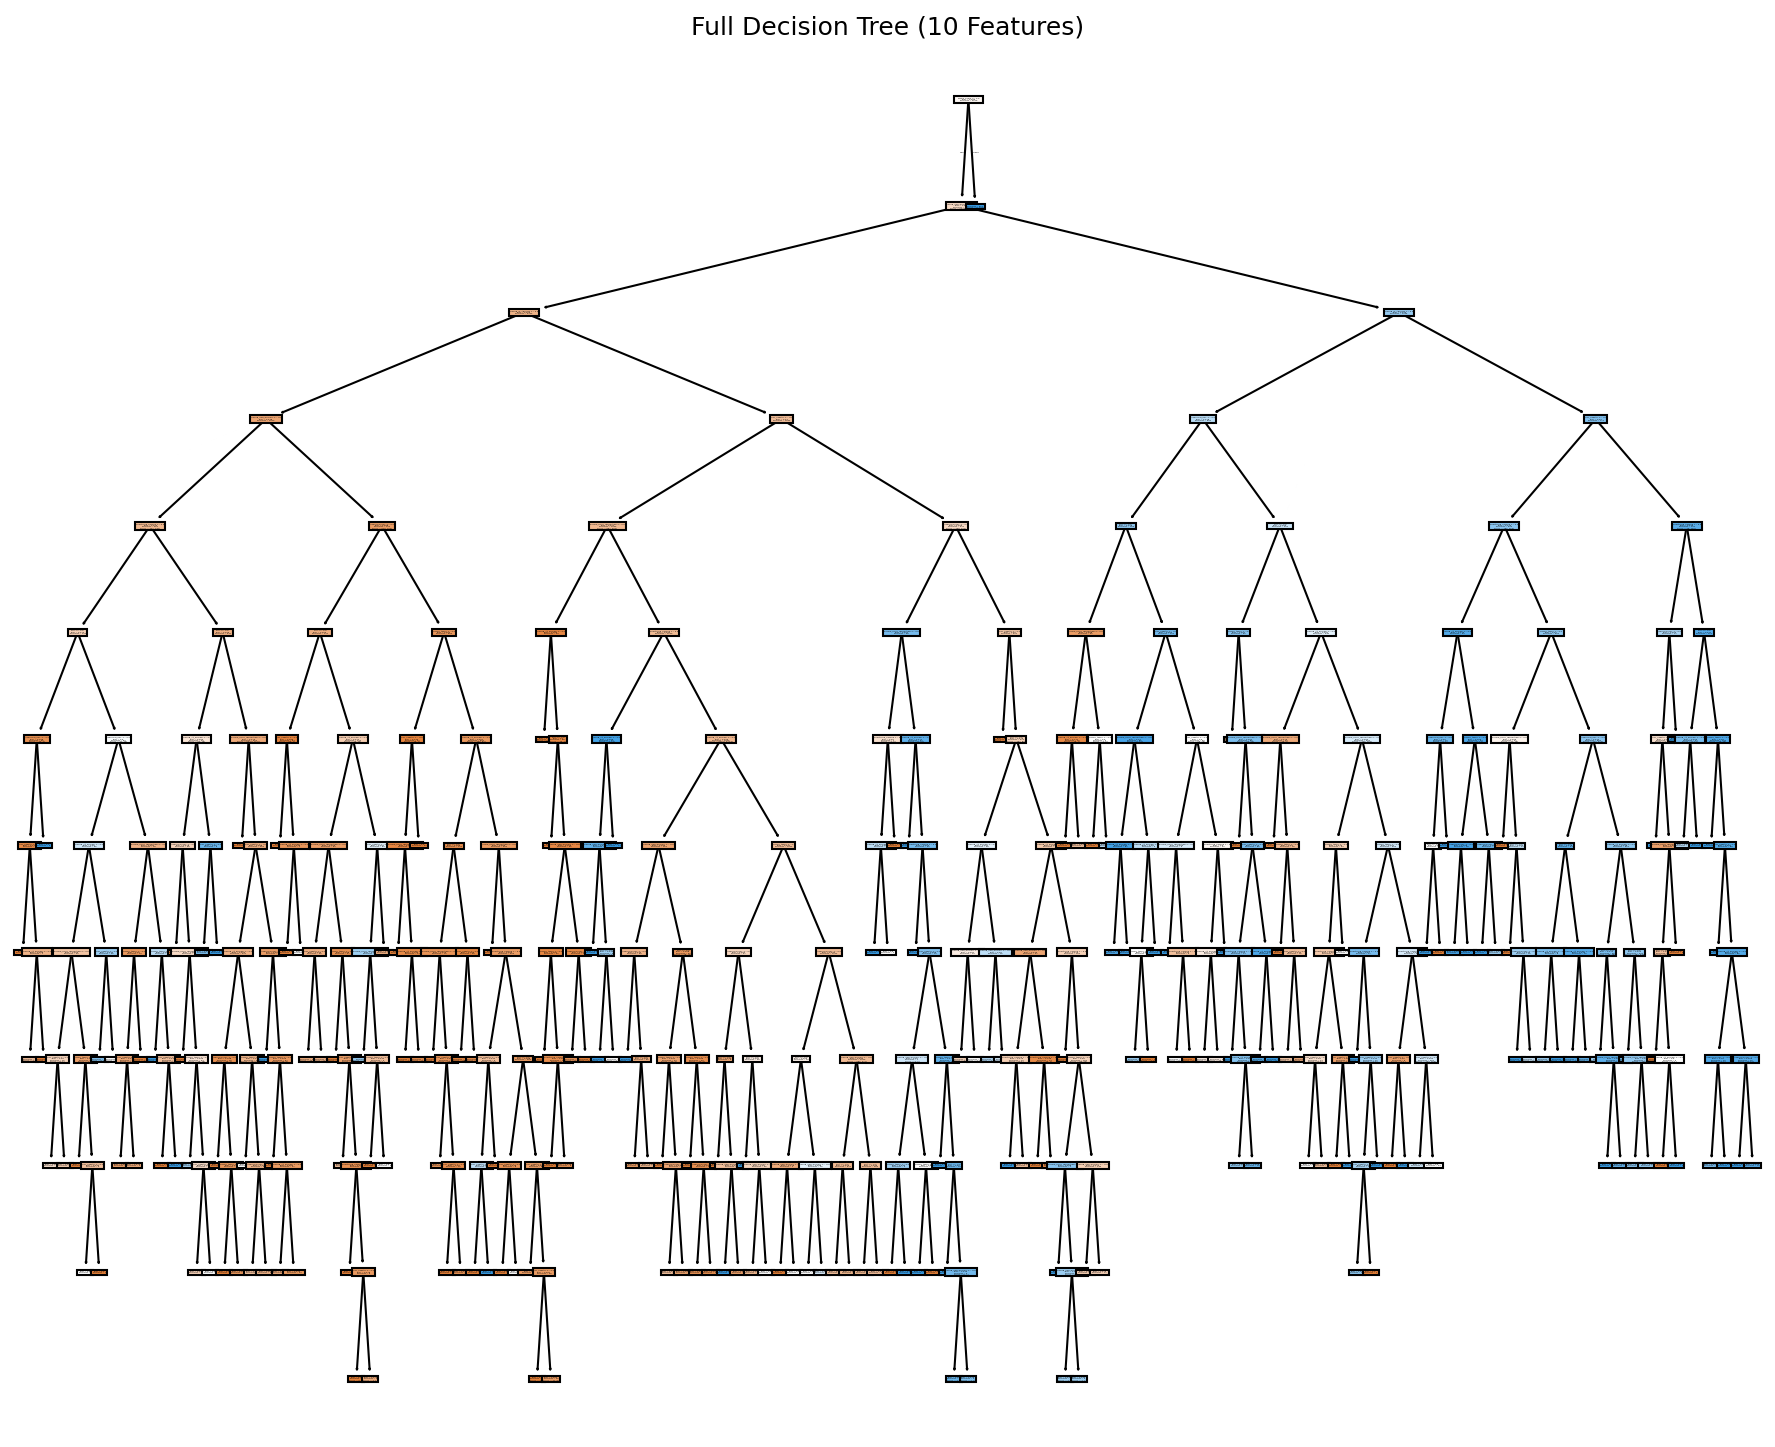

In [30]:
# Visualizing the full decision tree
from sklearn.tree import plot_tree
plt.figure(figsize=(15, 12), dpi=150)
plot_tree(dtree, filled=True, feature_names=X_train.columns)
plt.title("Full Decision Tree (10 Features)")
plt.show()


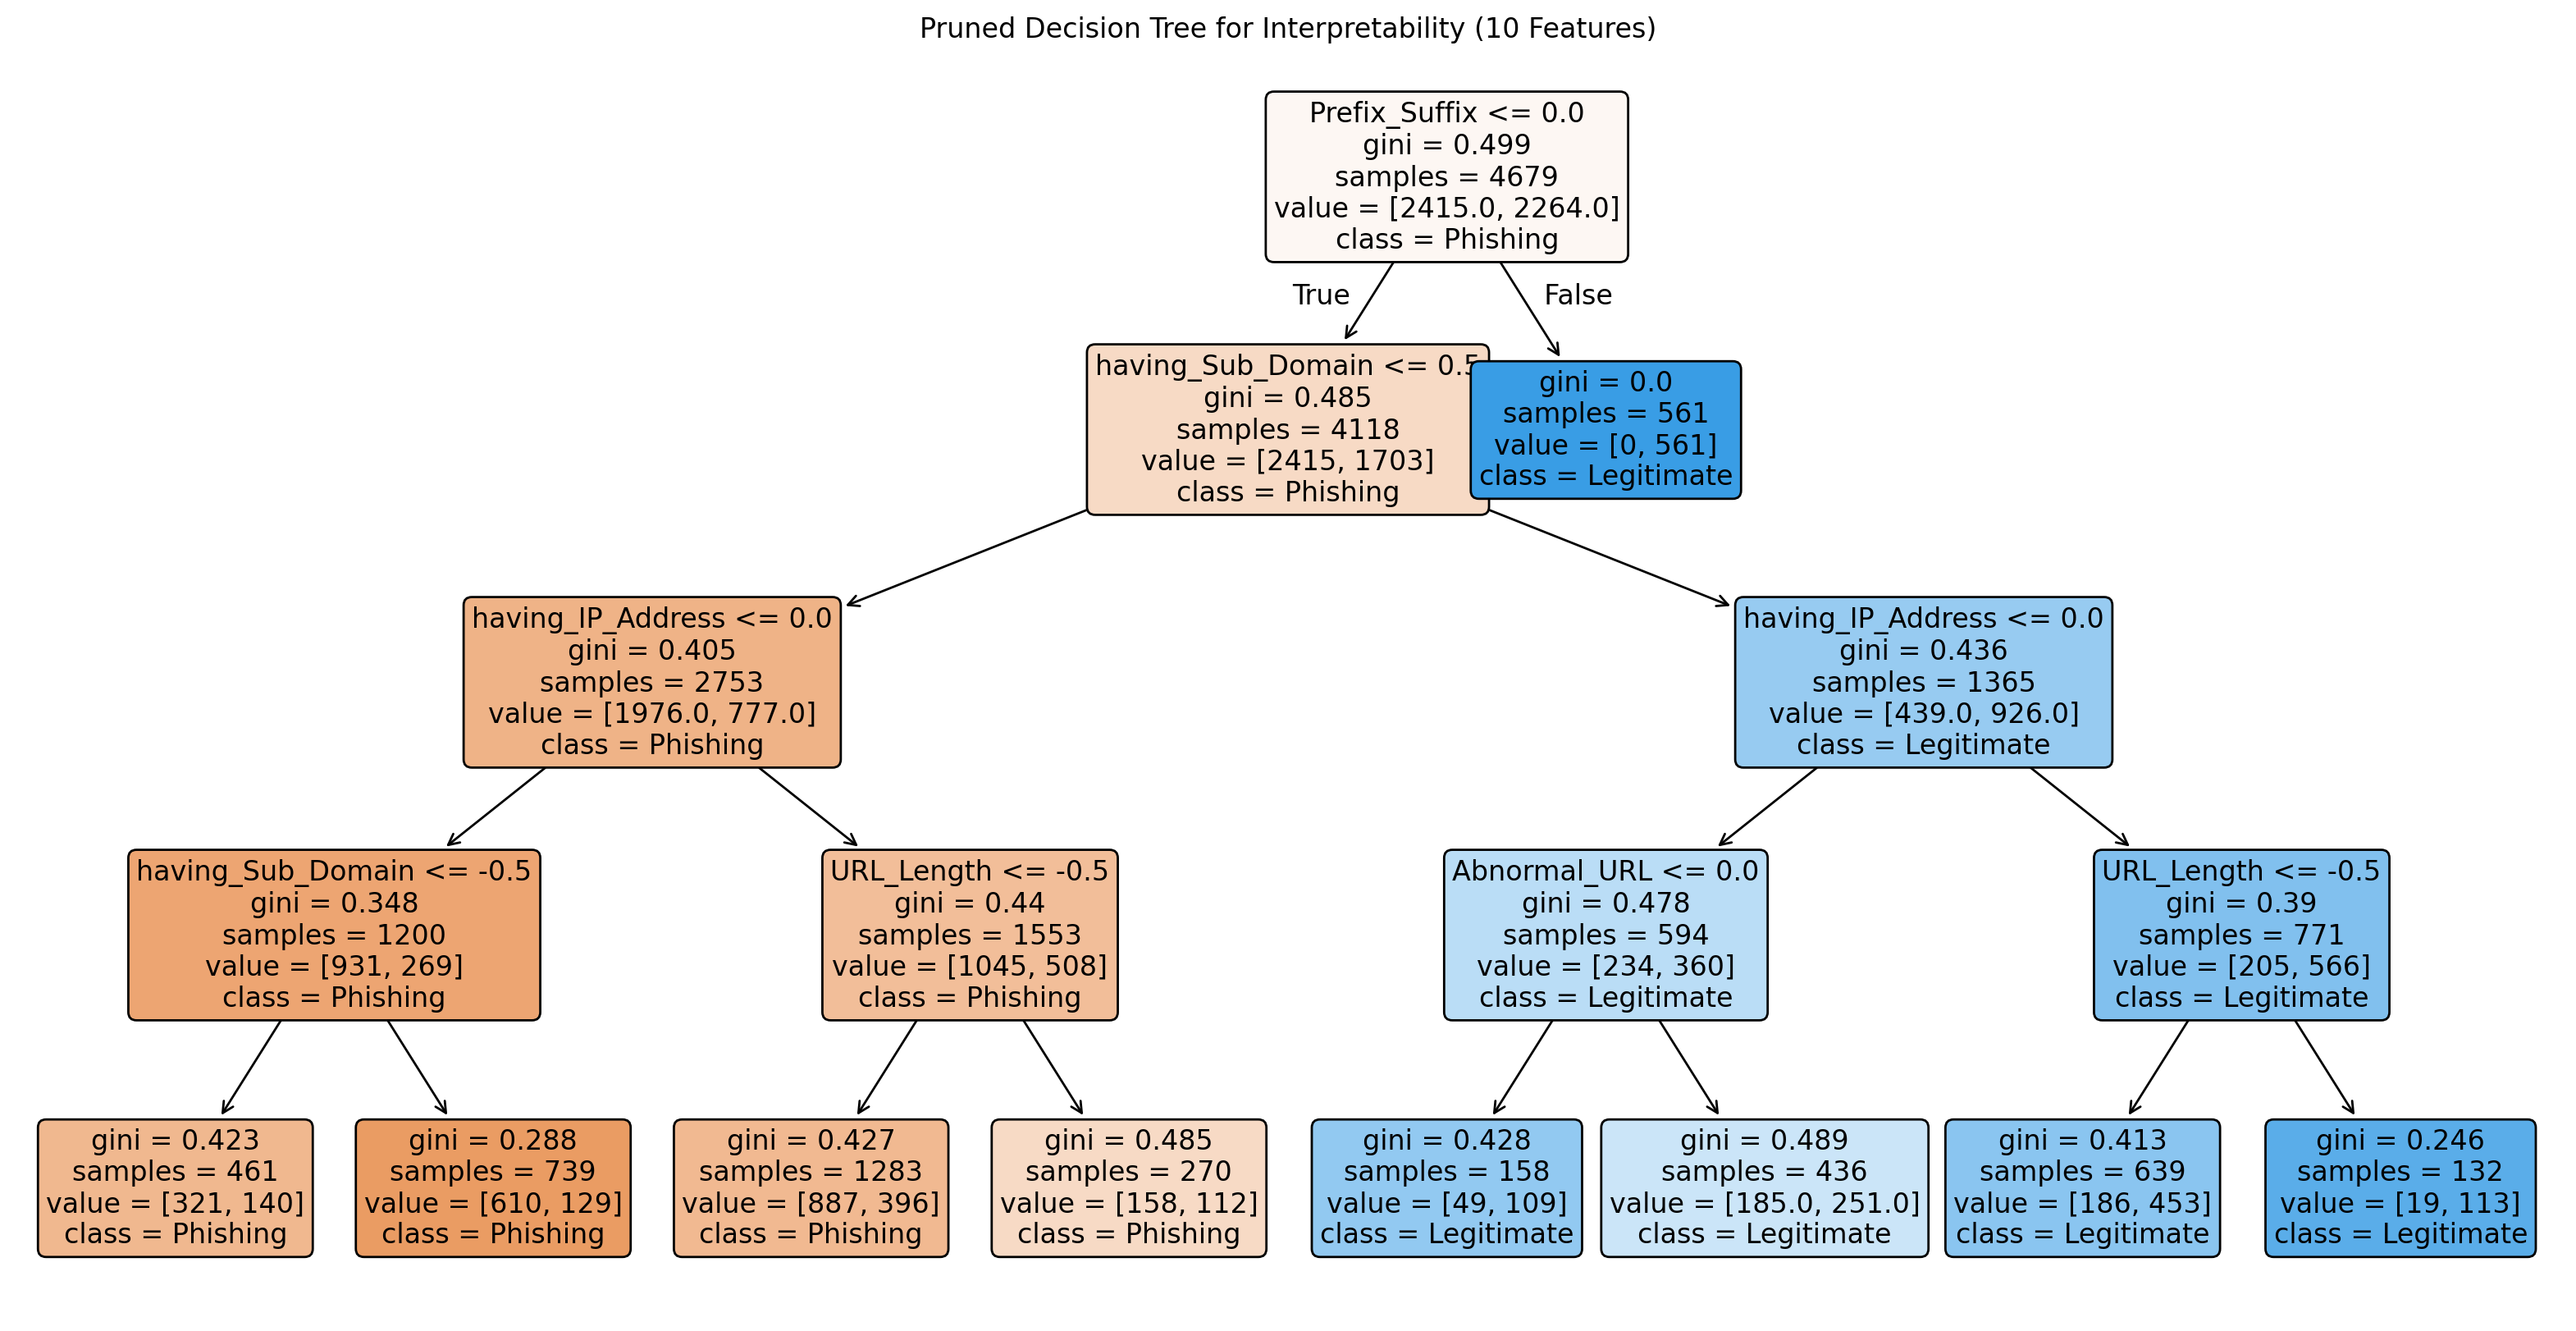

Pruned Test Accuracy: 0.7427


In [31]:
# Creating a pruned tree for better interpretability
dtree_pruned = DecisionTreeClassifier(max_depth=4, random_state=42)
dtree_pruned.fit(X_train, y_train)
# Visualizing the pruned tree
plt.figure(figsize=(20, 10), dpi=200)
plot_tree( dtree_pruned,filled=True, feature_names=X_train.columns,class_names=['Phishing', 'Legitimate'],rounded=True,fontsize=12)
plt.title("Pruned Decision Tree for Interpretability (10 Features)")
plt.show()
# Checking accuracy of the pruned tree
print(f"Pruned Test Accuracy: {dtree_pruned.score(X_test, y_test):.4f}")

# Random Forest

In [33]:
from sklearn.ensemble import RandomForestClassifier
# Creating Random Forest Model
# n_estimators=100 means we are building 100 trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [34]:
# Training the model
rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [35]:
# Making Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [36]:
# Evaluating the model
# Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.7401709401709402

Classification Report:
              precision    recall  f1-score   support

          -1       0.72      0.81      0.76       604
           1       0.77      0.66      0.71       566

    accuracy                           0.74      1170
   macro avg       0.74      0.74      0.74      1170
weighted avg       0.74      0.74      0.74      1170


Confusion Matrix:
[[490 114]
 [190 376]]


Random Forest ROC-AUC Score: 0.817785727657782


<Figure size 700x700 with 0 Axes>

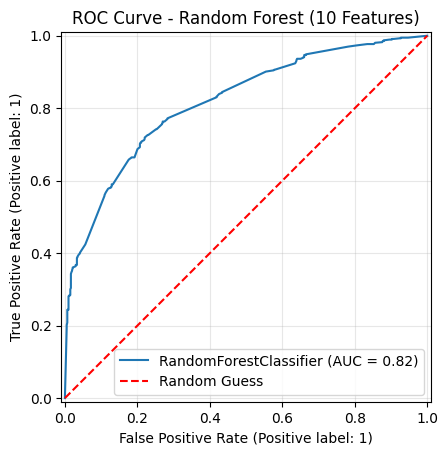

In [37]:
# ROC-AUC Score
rf_auc = roc_auc_score(y_test, y_prob_rf)
print("Random Forest ROC-AUC Score:", rf_auc)
# ROC Curve
plt.figure(figsize=(7,7))
RocCurveDisplay.from_estimator(rf_model, X_test, y_test)
plt.plot([0,1],[0,1],'r--', label="Random Guess")
plt.title("ROC Curve - Random Forest (10 Features)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

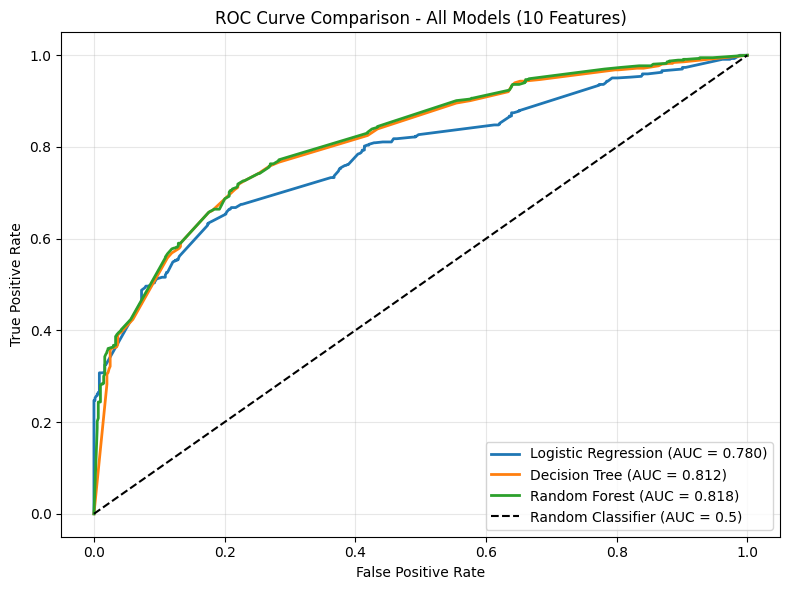

In [38]:
# Comparing ROC Curves of All Models (10 Features)
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability predictions for each model
y_prob_lr = logit_model.predict_proba(X_test_scaled)[:, 1]
y_prob_dt = dtree.predict_proba(X_test)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# Calculate AUC scores
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_dt = roc_auc_score(y_test, y_prob_dt)
auc_rf = roc_auc_score(y_test, y_prob_rf)

# Plot all three ROC curves together
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})", linewidth=2)
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})", linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier (AUC = 0.5)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - All Models (10 Features)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_comparison_10features.png", dpi=300, bbox_inches="tight")
plt.show()

                 Model  Accuracy
0  Logistic Regression  0.732479
1        Decision Tree  0.742735
2        Random Forest  0.740171


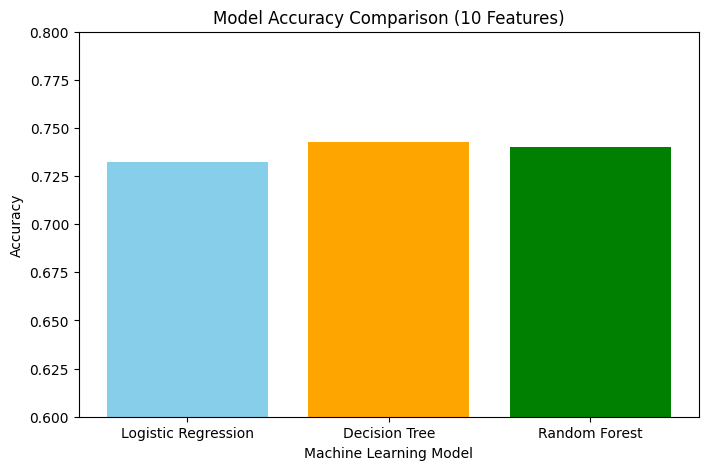

In [39]:
# Comparing performance of all baseline models (10 Features)
model_results = pd.DataFrame({"Model": ["Logistic Regression", "Decision Tree", "Random Forest"],"Accuracy": [logit_accuracy, dt_accuracy, rf_accuracy]})
print(model_results)
plt.figure(figsize=(8, 5))
plt.bar(model_results["Model"], model_results["Accuracy"],color=["skyblue", "orange", "green"])
plt.title("Model Accuracy Comparison (10 Features)")
plt.ylabel("Accuracy")
plt.xlabel("Machine Learning Model")
plt.ylim(0.6, 0.8)  # Updated range for 10 features
plt.show()

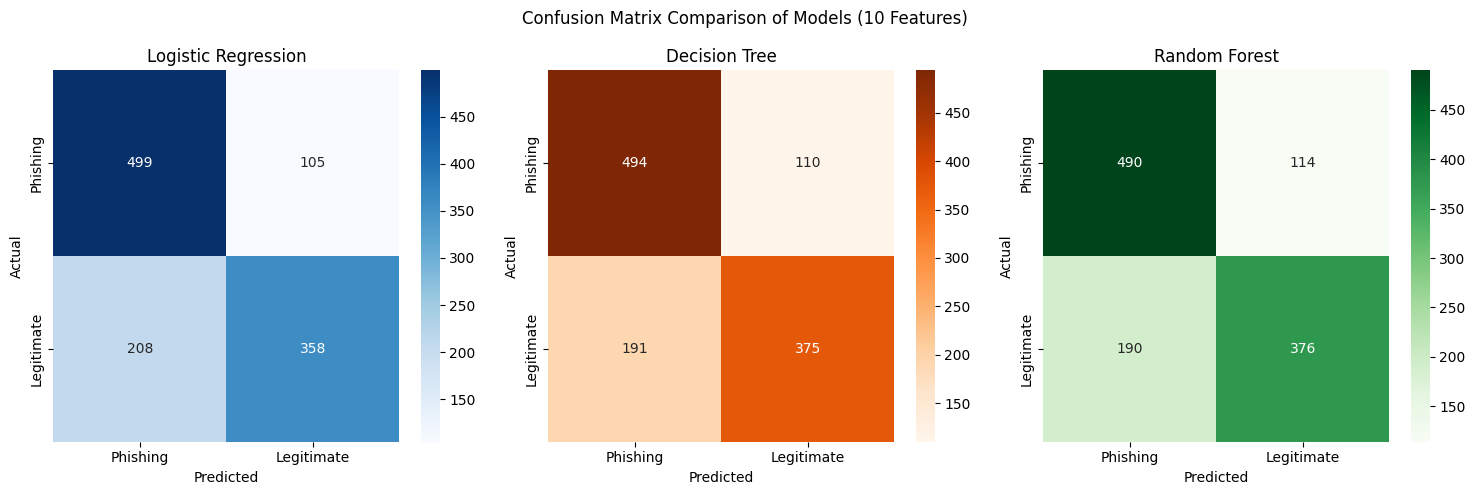

In [40]:
# Confusion Matrix Comparison (10 Features)
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",xticklabels=["Phishing", "Legitimate"],yticklabels=["Phishing", "Legitimate"], ax=axes[0])
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Oranges",xticklabels=["Phishing", "Legitimate"],yticklabels=["Phishing", "Legitimate"], ax=axes[1])
axes[1].set_title("Decision Tree")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",xticklabels=["Phishing", "Legitimate"],yticklabels=["Phishing", "Legitimate"], ax=axes[2])
axes[2].set_title("Random Forest")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")
plt.suptitle("Confusion Matrix Comparison of Models (10 Features)")
plt.tight_layout()
plt.show()

## Cross-Dataset Validation on PhishTank Dataset
In this section, the Random Forest model trained on the UCI dataset (10 features) is applied to the PhishTank dataset to evaluate its ability to detect real-world phishing URLs.

In [42]:
# Cross-dataset validation on PhishTank
phish_df = pd.read_csv("PhishTank_10_features.csv")

features_10 = [
    'having_IP_Address',
    'URL_Length',
    'Shortining_Service',
    'having_At_Symbol',
    'double_slash_redirecting',
    'Prefix_Suffix',
    'having_Sub_Domain',
    'HTTPS_token',
    'port',
    'Abnormal_URL']

X_phish = phish_df[features_10]
y_true = phish_df['Result']

# Applying the trained Random Forest model
y_pred = rf_model.predict(X_phish)

# Since PhishTank contains only phishing URLs (-1),
# this measures how many real phishing URLs were detected as phishing
phishing_detected = (y_pred == -1).sum()
total_urls = len(y_true)
detection_rate = phishing_detected / total_urls

print("Total URLs:", total_urls)
print("Phishing URLs detected:", phishing_detected)
print("Phishing Detection Rate:", detection_rate)

print("\nPrediction Distribution:")
print(pd.Series(y_pred).value_counts())

Total URLs: 56087
Phishing URLs detected: 11036
Phishing Detection Rate: 0.19676573894128765

Prediction Distribution:
 1    45051
-1    11036
Name: count, dtype: int64


In [43]:
print("False Negatives (missed phishing):", (y_pred == 1).sum())

False Negatives (missed phishing): 45051


In [44]:
print(f"\nPhishing Detection Rate: {detection_rate*100:.2f}%")


Phishing Detection Rate: 19.68%


Total URLs: 56087
Phishing URLs detected: 11036
Phishing Detection Rate: 0.1968

Classification Report:
                precision    recall  f1-score   support

 Phishing (-1)       1.00      0.20      0.33     56087
Legitimate (1)       0.00      0.00      0.00         0

      accuracy                           0.20     56087
     macro avg       0.50      0.10      0.16     56087
  weighted avg       1.00      0.20      0.33     56087



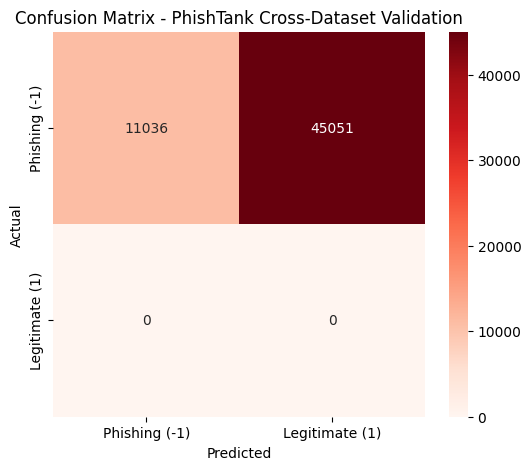

In [45]:
# Basic evaluation
total_urls = len(y_true)
phishing_detected = (y_pred == -1).sum()
detection_rate = phishing_detected / total_urls
print(f"Total URLs: {total_urls}")
print(f"Phishing URLs detected: {phishing_detected}")
print(f"Phishing Detection Rate: {detection_rate:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_true,y_pred,labels=[-1, 1],target_names=['Phishing (-1)', 'Legitimate (1)'],zero_division=0))
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',xticklabels=['Phishing (-1)', 'Legitimate (1)'],yticklabels=['Phishing (-1)', 'Legitimate (1)'])
plt.title('Confusion Matrix - PhishTank Cross-Dataset Validation')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [46]:
# Compare feature distributions between UCI training data and PhishTank
features_10 = ['having_IP_Address', 'URL_Length', 'Shortining_Service','having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix',
    'having_Sub_Domain', 'HTTPS_token', 'port', 'Abnormal_URL']
# UCI feature means (from training data X_train + X_test combined)
uci_means = X[features_10].mean()
# PhishTank feature means
phish_df = pd.read_csv('PhishTank_10_features.csv')
phish_means = phish_df[features_10].mean()
comparison = pd.DataFrame({'UCI Mean': uci_means.round(3),'PhishTank Mean': phish_means.round(3),'Difference': (phish_means - uci_means).round(3)})
print(comparison)

                          UCI Mean  PhishTank Mean  Difference
having_IP_Address            0.133           0.995       0.862
URL_Length                  -0.616           0.486       1.102
Shortining_Service           0.720           0.871       0.151
having_At_Symbol             0.589           0.982       0.394
double_slash_redirecting     0.718           0.974       0.256
Prefix_Suffix               -0.760           0.433       1.193
having_Sub_Domain            0.066           0.284       0.218
HTTPS_token                  0.654           0.968       0.314
port                         0.678           1.000       0.322
Abnormal_URL                 0.678           1.000       0.322


In [47]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Logistic Regression with scaling inside pipeline
lr_pipeline = Pipeline([('scaler', StandardScaler()),('model', LogisticRegression(max_iter=2000, random_state=42))])
lr_cv_scores = cross_val_score(lr_pipeline, X, y, cv=cv, scoring='accuracy')
dt_cv_scores = cross_val_score(DecisionTreeClassifier(random_state=42), X, y, cv=cv, scoring='accuracy')
rf_cv_scores = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42), X, y, cv=cv, scoring='accuracy')
print("Logistic Regression CV Scores:", lr_cv_scores)
print("Logistic Regression Mean CV Accuracy:", np.mean(lr_cv_scores))
print("\nDecision Tree CV Scores:", dt_cv_scores)
print("Decision Tree Mean CV Accuracy:", np.mean(dt_cv_scores))
print("\nRandom Forest CV Scores:", rf_cv_scores)
print("Random Forest Mean CV Accuracy:", np.mean(rf_cv_scores))

Logistic Regression CV Scores: [0.71196581 0.72905983 0.71965812 0.72905983 0.73224979]
Logistic Regression Mean CV Accuracy: 0.7243986751771183

Decision Tree CV Scores: [0.76068376 0.74444444 0.74871795 0.75982906 0.75962361]
Decision Tree Mean CV Accuracy: 0.7546597647196449

Random Forest CV Scores: [0.75982906 0.74615385 0.74358974 0.76324786 0.76133447]
Random Forest Mean CV Accuracy: 0.7548309973459674


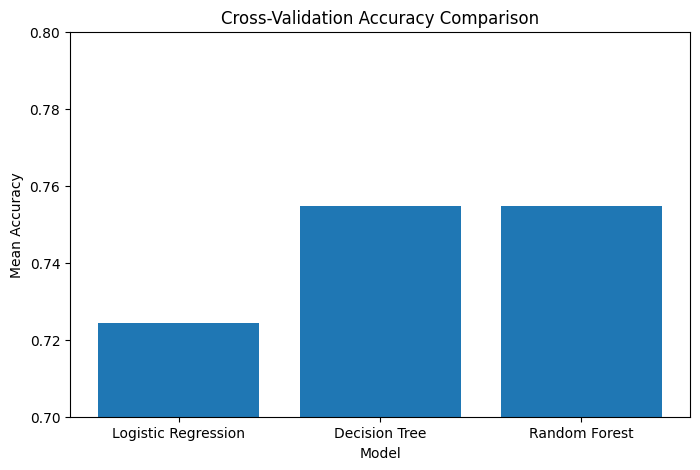

In [48]:
# Plotting mean cross-validation accuracy for each model
# This helps compare overall performance of the models
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
cv_means = [lr_cv_scores.mean(),dt_cv_scores.mean(),rf_cv_scores.mean()]
plt.figure(figsize=(8,5))
plt.bar(models, cv_means)
plt.title("Cross-Validation Accuracy Comparison")
plt.ylabel("Mean Accuracy")
plt.xlabel("Model")
plt.ylim(0.70, 0.80)
plt.show()

# XAI on Random Forest (LIME + SHAP)

In [50]:
!pip install shap

In [51]:
import shap

In [52]:
# Create SHAP explainer
explainer = shap.TreeExplainer(rf_model)

In [53]:
# Initialising SHAP TreeExplainer
# TreeExplainer is optimised for ensemble tree models like Random Forest
explainer = shap.TreeExplainer(rf_model)
# Calculating SHAP values for the test dataset (UCI 10 features)
shap_values = explainer.shap_values(X_test)
print("SHAP values shape:", shap_values.shape)

SHAP values shape: (1170, 10, 2)


In [54]:
# Extract SHAP values for both classes
# Class 0 = phishing (-1)
# Class 1 = legitimate (1)
shap_values_phishing = shap_values[:, :, 0]
shap_values_legitimate = shap_values[:, :, 1]
print("Phishing SHAP shape:", shap_values_phishing.shape)
print("Legitimate SHAP shape:", shap_values_legitimate.shape)

Phishing SHAP shape: (1170, 10)
Legitimate SHAP shape: (1170, 10)


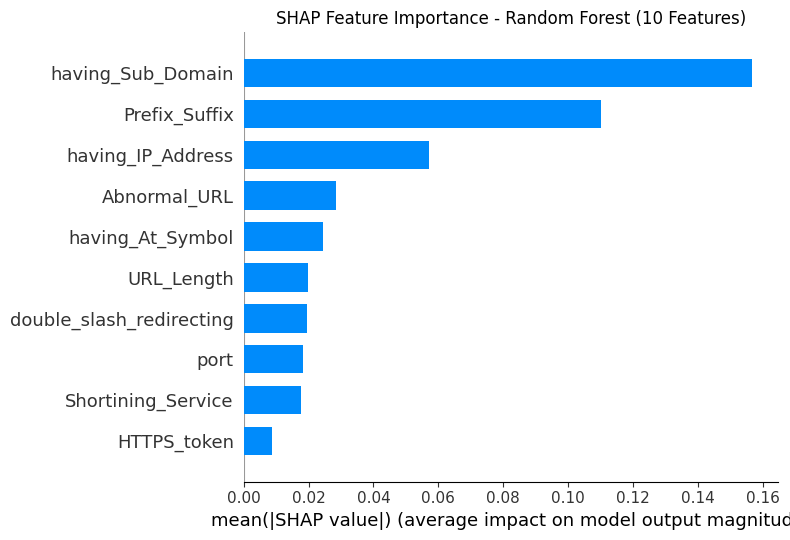

In [55]:
# SHAP Summary Plot - Bar chart (Global Feature Importance)
shap.summary_plot(shap_values_legitimate, X_test,feature_names=selected_features,plot_type="bar",show=False)  # Changed to False
plt.title("SHAP Feature Importance - Random Forest (10 Features)")
plt.tight_layout()
plt.show()

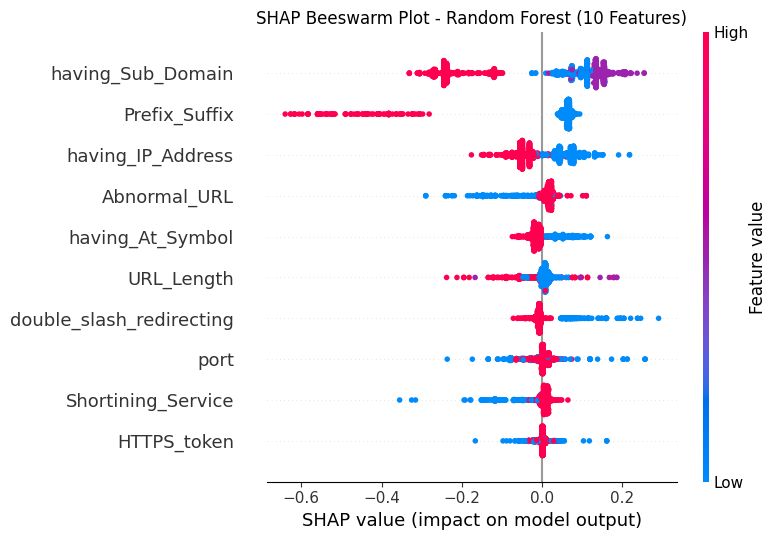

In [56]:
# SHAP Beeswarm Plot - shows magnitude AND direction of each feature
# for the phishing class (10 Features)
shap.summary_plot(shap_values_phishing, X_test,feature_names=selected_features,show=False)
plt.title("SHAP Beeswarm Plot - Random Forest (10 Features)")
plt.tight_layout()
plt.show()

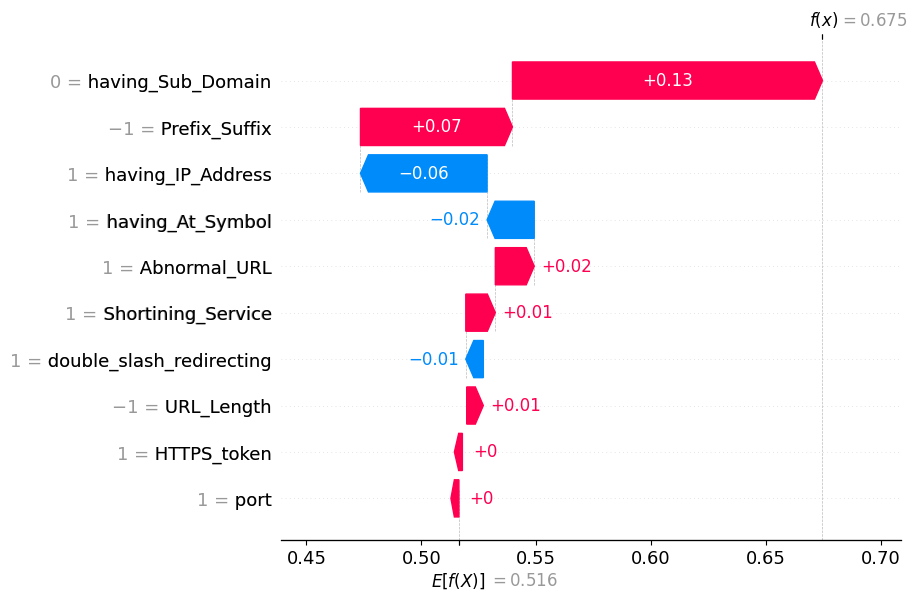

In [57]:
# SHAP Waterfall Plot - explaining one correctly classified phishing prediction (10 Features)
y_pred_rf = rf_model.predict(X_test)
correct_phishing = np.where((y_test.values == -1) & (y_pred_rf == -1))[0]
sample_index = correct_phishing[0]
shap.plots.waterfall(shap.Explanation(values=shap_values_phishing[sample_index], base_values=explainer.expected_value[0], data=X_test.iloc[sample_index], feature_names=selected_features))

Found 39 legitimate samples with 0.85-0.95 confidence
Selected sample index: 39
Prediction probability: [0.14776344 0.85223656]


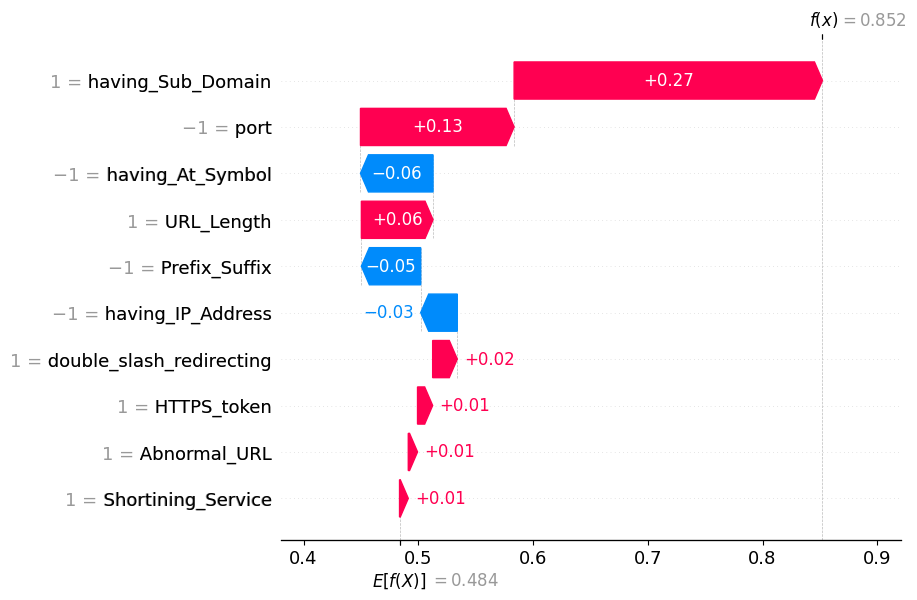

In [58]:
# SHAP Waterfall Plot - explaining one correctly classified legitimate prediction (10 Features)
correct_legitimate = np.where((y_test.values == 1) & (y_pred_rf == 1))[0]
# Get prediction probabilities for legitimate class for all correctly classified legit samples
legit_probs = rf_model.predict_proba(X_test.iloc[correct_legitimate])[:, 1]
# Filter samples with confidence between 0.85 and 0.95 (high confidence but not extreme)
moderate_mask = (legit_probs >= 0.85) & (legit_probs <= 0.95)
moderate_indices = correct_legitimate[moderate_mask]
print(f"Found {len(moderate_indices)} legitimate samples with 0.85-0.95 confidence")
# Pick the first moderate-confidence sample
sample_legit = moderate_indices[0]
# Print to verify
print(f"Selected sample index: {sample_legit}")
print(f"Prediction probability: {rf_model.predict_proba(X_test.iloc[[sample_legit]])[0]}")
# Generate the waterfall plot
shap.plots.waterfall(shap.Explanation(values=shap_values_legitimate[sample_legit], base_values=explainer.expected_value[1], data=X_test.iloc[sample_legit], feature_names=selected_features))

In [59]:
# Import LIME library for local explainability
import lime
import lime.lime_tabular

In [126]:
# Create LIME explainer using the training data (10 Features)
np.random.seed(42) 
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=selected_features,
    class_names=["Phishing", "Legitimate"],
    mode="classification"
)
print("LIME explainer created successfully")

LIME explainer created successfully


In [128]:
# Check class order used by the Random Forest model
print("Random Forest classes:", rf_model.classes_)

Random Forest classes: [-1  1]


Correctly classified phishing samples: 490
First correct index: 1

Actual Label: -1
Predicted Label: -1
Prediction Probabilities: [0.67455406 0.32544594]


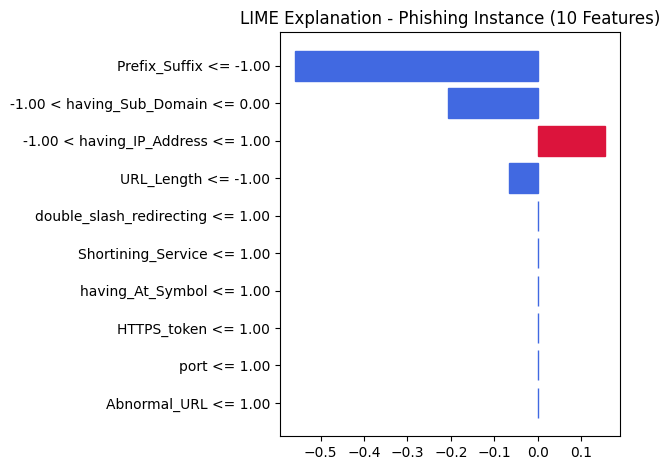

In [130]:
# Finding a correctly classified phishing sample
y_test_array = y_test.values
y_pred_array = rf_model.predict(X_test)
# Find indices where actual = -1 AND predicted = -1
correct_phishing = np.where((y_test_array == -1) & (y_pred_array == -1))[0]
print("Correctly classified phishing samples:", len(correct_phishing))
print("First correct index:", correct_phishing[0])
# Use first correctly classified phishing sample
sample_index = correct_phishing[0]
actual_label = y_test.iloc[sample_index]
predicted_label = rf_model.predict(X_test.iloc[[sample_index]])[0]
predicted_prob = rf_model.predict_proba(X_test.iloc[[sample_index]])[0]
print("\nActual Label:", actual_label)
print("Predicted Label:", predicted_label)
print("Prediction Probabilities:", predicted_prob)
# Generate LIME explanation
lime_exp = lime_explainer.explain_instance(
    data_row=X_test.iloc[sample_index].values,
    predict_fn=rf_model.predict_proba,
    num_features=10)
fig = lime_exp.as_pyplot_figure()
# Apply custom colours to match Experiment 1
for bar in plt.gca().patches:
    if bar.get_width() > 0:
        bar.set_color('crimson')      # positive weight
    else:
        bar.set_color('royalblue')    # negative weight
plt.title("LIME Explanation - Phishing Instance (10 Features)")
plt.tight_layout()
plt.savefig("lime_phishing_instance_10features.png", dpi=300, bbox_inches="tight")
plt.show()

Selected sample index: 39
Actual Label: 1
Predicted Label: 1
Prediction Probabilities: [0.14776344 0.85223656]


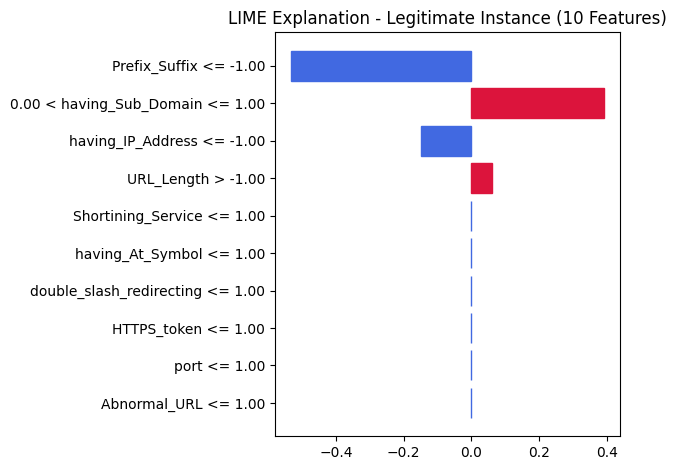

In [132]:
# Generate LIME explanation for one legitimate sample (10 Features)
# Use the same sample as SHAP (moderate confidence 0.85-0.95) for consistency
legit_positions = np.where((y_test.values == 1) & (y_pred_array == 1))[0]

# Filter to moderate-confidence legitimate samples (matching SHAP cell)
legit_probs = rf_model.predict_proba(X_test.iloc[legit_positions])[:, 1]
moderate_mask = (legit_probs >= 0.85) & (legit_probs <= 0.95)
moderate_indices = legit_positions[moderate_mask]

# Pick the first moderate-confidence sample (same as SHAP)
sample_legit = moderate_indices[0]

actual_label_legit = y_test.iloc[sample_legit]
predicted_label_legit = rf_model.predict(X_test.iloc[[sample_legit]])[0]
predicted_prob_legit = rf_model.predict_proba(X_test.iloc[[sample_legit]])[0]
print("Selected sample index:", sample_legit)
print("Actual Label:", actual_label_legit)
print("Predicted Label:", predicted_label_legit)
print("Prediction Probabilities:", predicted_prob_legit)

lime_exp_legit = lime_explainer.explain_instance(data_row=X_test.iloc[sample_legit].values,predict_fn=rf_model.predict_proba,num_features=10)
fig = lime_exp_legit.as_pyplot_figure()
# Apply custom colours to match Experiment 1
for bar in plt.gca().patches:
    if bar.get_width() > 0:
        bar.set_color('crimson')      # positive weight
    else:
        bar.set_color('royalblue')    # negative weight
plt.title("LIME Explanation - Legitimate Instance (10 Features)")
plt.tight_layout()
plt.savefig("lime_legitimate_instance_10features.png", dpi=300, bbox_inches="tight")
plt.show()